# 06 – Végső kiértékelés (Test Set)

**FONTOS: Ez az egyetlen notebook amely TEST adatot tölt be.**

A test split-et kizárólag itt, egyszer töltjük be. Minden más notebook csak train/val adatot lát.

**Cél:** A legjobb ML (SVM) és a legjobb CNN modell végső összehasonlítása a test set-en.

**Betöltött modellek:**
- `checkpoints/best_ml_model.pkl` — legjobb sklearn modell (05a-ból)
- `checkpoints/best_mobilenet_v3_*.pth` — legjobb CNN (05b-ből)

In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import torch
import torch.nn as nn
from pathlib import Path
from sklearn.metrics import (accuracy_score, f1_score,
                              confusion_matrix, classification_report)

from src.config import CFG, PATHS
from src.features import load_features, feature_names
from src.dataset import get_dataloaders
from src.models import build_model
from src.train import evaluate, load_checkpoint

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT_DIR = PATHS['output_dir'] / '06_evaluation'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Device: {DEVICE}')

## 1. Test adatok betöltése

In [6]:
# Feature vektor – test split
data = load_features()
X = data['X']
y = data['y']
classes = data['classes']
splits = np.array(data['splits'])
fn = feature_names()

test_mask = splits == 'test'
X_test, y_test = X[test_mask], y[test_mask]
B_cols = list(range(42))

print(f'Test set: {len(X_test)} kép  |  Classes: {classes}')

# Kép DataLoader – test split
_, _, test_img_loader, classes_img, _ = get_dataloaders(device=DEVICE)
assert classes == classes_img, 'Osztályok nem egyeznek!'

Test set: 45 kép  |  Classes: [np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('No hand')]


## 2. ML modell kiértékelés

In [7]:
ml_ckpt = PATHS['checkpoint_dir'] / 'best_ml_model.pkl'
if not ml_ckpt.exists():
    print(f'HIÁNYZIK: {ml_ckpt}  – futtasd a 05a notebookot!')
else:
    with open(ml_ckpt, 'rb') as f:
        ml_data = pickle.load(f)
    
    ml_model = ml_data['model']
    ml_name  = ml_data['name']
    
    # Group B-only ha SVM_B
    expected_features = getattr(ml_model, 'n_features_in_', X_test.shape[1])
    if expected_features == len(B_cols):
        X_test_ml = X_test[:, B_cols]
    else:
        X_test_ml = X_test
    pred_ml = ml_model.predict(X_test_ml)
    
    acc_ml = accuracy_score(y_test, pred_ml)
    f1_ml  = f1_score(y_test, pred_ml, average='macro')
    print(f'ML ({ml_name}, {expected_features} dim)  test_acc={acc_ml:.3f}  macro_f1={f1_ml:.3f}')
    print(f'val_acc (edzéskor): {ml_data["val_acc"]:.3f}')

ML (SVM (Group B, 42d), 42 dim)  test_acc=0.911  macro_f1=0.907
val_acc (edzéskor): 0.956


## 3. Legjobb CNN kiértékelés

In [8]:
cnn_meta_path = PATHS['output_dir'] / '05b_cnn_finetune' / 'best_cnn_meta.json'
if not cnn_meta_path.exists():
    print(f'HIÁNYZIK: {cnn_meta_path}  – futtasd a 05b notebookot!')
    HAS_CNN = False
else:
    with open(cnn_meta_path) as f:
        cnn_meta = json.load(f)
    
    cnn_name = cnn_meta['best_cnn_name'].lower().replace(' ', '_').replace('-', '_')
    # Map display name → build_model name
    name_map = {
        'mobilenetv3_small': 'mobilenet_v3_small',
        'mobilenetv3_large': 'mobilenet_v3_large',
        'efficientnet_b0':   'efficientnet_b0',
    }
    build_name = name_map.get(cnn_name, cnn_name)
    
    cnn_model = build_model(build_name, num_classes=len(classes)).to(DEVICE)
    cnn_ckpt_path = Path(cnn_meta['best_cnn_ckpt'])
    if cnn_ckpt_path.exists():
        cnn_model = load_checkpoint(cnn_model, cnn_ckpt_path, DEVICE)
        criterion = nn.CrossEntropyLoss()
        _, acc_cnn, preds_cnn, labels_cnn = evaluate(
            cnn_model, test_img_loader, criterion, DEVICE)
        f1_cnn = f1_score(labels_cnn, preds_cnn, average='macro')
        print(f'CNN ({cnn_meta["best_cnn_name"]})  test_acc={acc_cnn:.3f}  macro_f1={f1_cnn:.3f}')
        print(f'val_acc (edzéskor): {cnn_meta["best_cnn_val_acc"]:.3f}')
        HAS_CNN = True
    else:
        print(f'HIÁNYZIK checkpoint: {cnn_ckpt_path}')
        HAS_CNN = False

CNN (MobileNetV3-Large)  test_acc=0.978  macro_f1=0.978
val_acc (edzéskor): 0.956


## 4. Összefoglaló + confusion matrix

In [9]:
print('\n' + '=' * 50)
print('VÉGSŐ ÖSSZEFOGLALÓ – TEST SET')
print('=' * 50)
if ml_ckpt.exists():
    print(f'ML  ({ml_name:<20})  test_acc={acc_ml:.3f}  F1={f1_ml:.3f}')
if HAS_CNN:
    print(f'CNN ({cnn_meta["best_cnn_name"]:<20})  test_acc={acc_cnn:.3f}  F1={f1_cnn:.3f}')
print('=' * 50)

if HAS_CNN:
    delta = acc_cnn - acc_ml
    print(f'Delta CNN-ML: {delta:+.3f}')
    if delta > 0.05:
        print('→ CNN >5% fölénye: CNN ajánlott')
    elif abs(delta) <= 0.03:
        print('→ Nincs érdemi különbség: feature-alapú SVM ajánlott (interpretálható, GPU nélküli)')
    else:
        print('→ ML jobb: SVM marad a legjobb modell')


VÉGSŐ ÖSSZEFOGLALÓ – TEST SET
ML  (SVM (Group B, 42d)  )  test_acc=0.911  F1=0.907
CNN (MobileNetV3-Large   )  test_acc=0.978  F1=0.978
Delta CNN-ML: +0.067
→ CNN >5% fölénye: CNN ajánlott


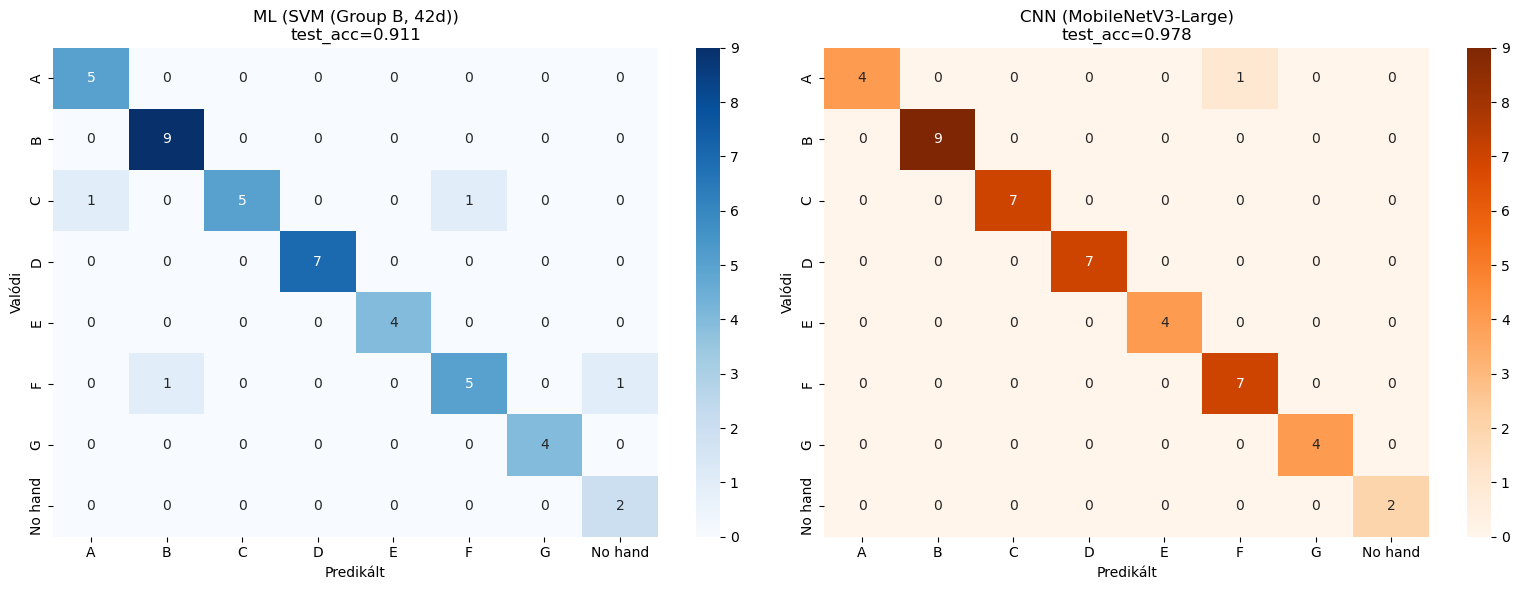

In [10]:
# Confusion matrix vizualizáció
n_plots = 1 + (1 if HAS_CNN else 0)
fig, axes = plt.subplots(1, n_plots, figsize=(8 * n_plots, 6))
if n_plots == 1:
    axes = [axes]

if ml_ckpt.exists():
    cm_ml = confusion_matrix(y_test, pred_ml)
    sns.heatmap(cm_ml, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=axes[0])
    axes[0].set_title(f'ML ({ml_name})\ntest_acc={acc_ml:.3f}')
    axes[0].set_xlabel('Predikált'); axes[0].set_ylabel('Valódi')

if HAS_CNN:
    cm_cnn = confusion_matrix(labels_cnn, preds_cnn)
    sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Oranges',
                xticklabels=classes, yticklabels=classes, ax=axes[1])
    axes[1].set_title(f'CNN ({cnn_meta["best_cnn_name"]})\ntest_acc={acc_cnn:.3f}')
    axes[1].set_xlabel('Predikált'); axes[1].set_ylabel('Valódi')

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'confusion_test.png', dpi=150)
plt.show()

In [11]:
# Per-class részletes riport
print('ML részletes riport (test set):')
print(classification_report(y_test, pred_ml,
                             target_names=[str(c) for c in classes], digits=3))

if HAS_CNN:
    print('CNN részletes riport (test set):')
    print(classification_report(labels_cnn, preds_cnn,
                                 target_names=[str(c) for c in classes], digits=3))

ML részletes riport (test set):
              precision    recall  f1-score   support

           A      0.833     1.000     0.909         5
           B      0.900     1.000     0.947         9
           C      1.000     0.714     0.833         7
           D      1.000     1.000     1.000         7
           E      1.000     1.000     1.000         4
           F      0.833     0.714     0.769         7
           G      1.000     1.000     1.000         4
     No hand      0.667     1.000     0.800         2

    accuracy                          0.911        45
   macro avg      0.904     0.929     0.907        45
weighted avg      0.921     0.911     0.909        45

CNN részletes riport (test set):
              precision    recall  f1-score   support

           A      1.000     0.800     0.889         5
           B      1.000     1.000     1.000         9
           C      1.000     1.000     1.000         7
           D      1.000     1.000     1.000         7
           E 

## 5. Vizuális mintaértékelés – sikeres és hibás predikcók

5 véletlenszerűen választott **sikeres** és (max 5) **hibás** predikció az SVM és CNN modellekre.  
A képek eredeti felbontásban, `figsize` max 12 inch, DPI 96, `interpolation='bilinear'`.

In [ ]:
import random
import cv2

random.seed(42)

# Tesztképek útvonalai – azonos sorrend mint X_test / y_test (features NPZ-ből)
test_paths = [p for p, s in zip(data['paths'], data['splits']) if s == 'test']
assert len(test_paths) == len(y_test), (
    f"Útvonal-szám ({len(test_paths)}) != feature-szám ({len(y_test)})"
)


def _show_samples(title, indices, pred_arr, true_arr, path_list, class_names):
    """Képrács megjelenítése prediktált és valódi osztálycímkével."""
    if not indices:
        print(f"  {title}: nincs megjeleníthető eset.")
        return
    n = len(indices)
    fig, axes = plt.subplots(
        1, n,
        figsize=(min(12.0, 2.4 * n), 3.5),
        constrained_layout=True,
        dpi=96,
    )
    if n == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=10, fontweight='bold')
    for ax, idx in zip(axes, indices):
        img = cv2.imread(str(path_list[idx]))
        if img is not None:
            ax.imshow(img[:, :, ::-1], interpolation='bilinear')
        else:
            ax.set_facecolor('#fee')
        ax.set_aspect('equal', adjustable='box')
        true_lbl = str(class_names[true_arr[idx]])
        pred_lbl = str(class_names[pred_arr[idx]])
        color = 'green' if true_lbl == pred_lbl else 'red'
        ax.set_title(f"Valódi: {true_lbl}\nPred: {pred_lbl}", fontsize=8, color=color)
        ax.axis('off')
    plt.show()


In [ ]:
# ── SVM vizuális mintaértékelés ──────────────────────────────────────────────
if ml_ckpt.exists():
    svm_correct = [i for i in range(len(y_test)) if pred_ml[i] == y_test[i]]
    svm_wrong   = [i for i in range(len(y_test)) if pred_ml[i] != y_test[i]]

    svm_ok_sample  = random.sample(svm_correct, min(5, len(svm_correct)))
    svm_err_sample = svm_wrong[:5]

    print(f'SVM – Helyes: {len(svm_correct)}/{len(y_test)}, Hibás: {len(svm_wrong)}')

    _show_samples(
        f'SVM ({ml_name}) – 5 véletlenszerű SIKERES predikció',
        svm_ok_sample, pred_ml, y_test, test_paths, classes,
    )
    if svm_err_sample:
        _show_samples(
            f'SVM ({ml_name}) – HIBÁS predikcók (max 5)',
            svm_err_sample, pred_ml, y_test, test_paths, classes,
        )
    else:
        print('SVM: Nincs hibás predikció a test seten!')


In [ ]:
# ── CNN vizuális mintaértékelés ──────────────────────────────────────────────
if HAS_CNN:
    preds_cnn_arr  = np.array(preds_cnn)
    labels_cnn_arr = np.array(labels_cnn)
    assert len(labels_cnn_arr) == len(test_paths), (
        f"CNN kimenet ({len(labels_cnn_arr)}) != teszt képek ({len(test_paths)})"
    )

    cnn_correct = [i for i in range(len(labels_cnn_arr))
                   if preds_cnn_arr[i] == labels_cnn_arr[i]]
    cnn_wrong   = [i for i in range(len(labels_cnn_arr))
                   if preds_cnn_arr[i] != labels_cnn_arr[i]]

    cnn_ok_sample  = random.sample(cnn_correct, min(5, len(cnn_correct)))
    cnn_err_sample = cnn_wrong[:5]

    print(f'CNN – Helyes: {len(cnn_correct)}/{len(labels_cnn_arr)}, Hibás: {len(cnn_wrong)}')

    _show_samples(
        f'CNN ({cnn_meta["best_cnn_name"]}) – 5 véletlenszerű SIKERES predikció',
        cnn_ok_sample, preds_cnn_arr, labels_cnn_arr, test_paths, classes,
    )
    if cnn_err_sample:
        _show_samples(
            f'CNN ({cnn_meta["best_cnn_name"]}) – HIBÁS predikcók (max 5)',
            cnn_err_sample, preds_cnn_arr, labels_cnn_arr, test_paths, classes,
        )
    else:
        print('CNN: Nincs hibás predikció a test seten!')


In [12]:
# Eredmény mentése
import json
summary = {
    'ml_model': ml_name if ml_ckpt.exists() else None,
    'ml_test_acc': float(acc_ml) if ml_ckpt.exists() else None,
    'ml_test_f1':  float(f1_ml)  if ml_ckpt.exists() else None,
    'cnn_model': cnn_meta['best_cnn_name'] if HAS_CNN else None,
    'cnn_test_acc': float(acc_cnn) if HAS_CNN else None,
    'cnn_test_f1':  float(f1_cnn)  if HAS_CNN else None,
}
with open(OUTPUT_DIR / 'final_results.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('Végső eredmények mentve:', OUTPUT_DIR / 'final_results.json')
print(json.dumps(summary, indent=2))

Végső eredmények mentve: /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/output/06_evaluation/final_results.json
{
  "ml_model": "SVM (Group B, 42d)",
  "ml_test_acc": 0.9111111111111111,
  "ml_test_f1": 0.9073779290884554,
  "cnn_model": "MobileNetV3-Large",
  "cnn_test_acc": 0.9777777777777777,
  "cnn_test_f1": 0.9777777777777779
}
